

# Non-FFT DSP Chain - Step-by-Step Walkthrough

End-to-end Python reference for the streaming non-FFT frontend path.
Corresponds to `planning/DSP Flow.md` and `planning/Non-FFT LoRa Frontend Proposal.md`.

**Chain under test:**

```
Modulate -> Channel -> Decimator -> DC Removal -> (Frontend Buffer 8-bit -> SC Preamble Detector)
        -> Training Accumulator -> Weight Generation -> [Noise Floor Estimation] -> Combiner -> Sigma-Delta Re-modulator -> Demodulate
```

Stage mapping to `planning/DSP Flow.md`:

| Stage | Block |
|---|---|
| 2 | Sigma-Delta Decimator (modelled as full-precision float) |
| 3 | DC Removal - IIR running mean, `DC_ALPHA_SHIFT=8` |
| 4 | Frontend Buffer -> 8-bit saturated samples for SC |
| 5 | SC Preamble Detector -> `sc_lock`, `timing_ref` |
| 6 | Training Accumulator -> `Z_j = sum rx_j[n] * conj(rx_ref[n])` (cross-correlation) |
| 7 | Weight Generation - `SHIFT -> CALIBRATE -> COMPUTE -> SCALE`, modes: MRC/EGC/SC/Bypass |
| 7b | Noise Floor Estimation - firmware EMA of idle-period `sum |x|^2 / M` -> per-branch `sigma^2_j` |
| 8 | Combiner - `y[n] = sum_j w_j x_j[n]`; NW-MRC uses `sigma^2_j` for per-branch weighting |
| 9 | Sigma-Delta Re-modulator - 3rd order, int16 -> 1-bit |

**Key properties of the non-FFT path:**
- No FFT engine, no capture SRAM, no RCTSL CFO estimation
- CFO cancels exactly in the cross-correlation: `Z_j = sum rx_j * conj(rx_ref)` eliminates Dirichlet nulling at all CFO values
- Weight Generation applies the current RTL `SHIFT` behavior: arithmetic right-shift by `sf` bits before calibration and weight computation
- The hardware MRC path is approximate: after `SHIFT` and `CALIBRATE`, weights are proportional to `conj(H_j)` with a shared power-of-two scale for headroom
- Full-precision samples (not 8-bit SRAM) feed the training accumulator and combiner
- Noise floor estimation requires no new RTL: it reuses the existing Energy Measurement outputs during IDLE state


In [ ]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../..').resolve()))

import matplotlib
matplotlib.use('Agg')
import numpy as np
import matplotlib.pyplot as plt

from sim.models.lora import modulate, demodulate
from sim.models.channel import rayleigh_coefficients, apply_channel
from sim.models.decimator import SigmaDeltaDecimator
from sim.models.dc_removal import DCRemoval
from sim.models.sync import SchmidlCoxDetector
from sim.models.stages import energy_detector
from sim.models.training_accumulator import (
    training_accumulate, training_accumulate_allpairs,
    compute_weights, compute_eigvec_weights, chirp_reference, cfo_diagnostic,
)
from sim.models.weight_generation import WeightGenerator, shift_normalise
from sim.models.receiver import nonfft_combine, nonfft_combine_rtl_int8w
from sim.models.converter import SigmaDeltaRemodulator
from sim.models.fixed import quantize, quantize_q1_15

rng = np.random.default_rng(42)
np.random.seed(42)   # seed global state used by apply_channel / rayleigh_coefficients
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True})

import io as _io
from IPython.display import Image as _Image, display as _ipy_display

def show(fig=None):
    """Render figure to PNG and display inline; works with Agg backend."""
    if fig is None:
        fig = plt.gcf()
    buf = _io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=110)
    buf.seek(0)
    _ipy_display(_Image(data=buf.read()))
    plt.close(fig)
from tqdm.auto import tqdm


/home/timothyjabez/Documents/chipathon-2026/chipathon-2026-trouper/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ── System constants ─────────────────────────────────────────────────────────
SF   = 6          # Spreading factor (SF6 = primary operating point)
M    = 2 ** SF    # Samples per symbol = 64
BW   = 125e3      # Bandwidth (Hz)
NR   = 4          # Receive antennas
N_PREAMBLE = 8    # LoRa preamble upchirp count
SC_HITS_REQ = 2   # SC consecutive hits to declare lock

# Training accumulator window
# sc_lock fires after SC_HITS_REQ hits, approximately (SC_HITS_REQ+1)·M samples in
# => ~5 of 8 preamble symbols accumulated; ~2 dB SNR penalty vs ideal
EXPECTED_N_ACC = (N_PREAMBLE - SC_HITS_REQ - 1) * M   # ≈ 320 samples at SF6

# SNR for the single-packet walkthrough cells (high enough that SC reliably locks)
# The BER sweep covers the full -15 to +5 dB range independently.
SNR_DB = 0.0
N0 = 10 ** (-SNR_DB / 10)

print(f'SF={SF}, M={M}, NR={NR}, SNR={SNR_DB} dB, N0={N0:.4f}')
print(f'Expected n_acc ≈ {EXPECTED_N_ACC} samples ({EXPECTED_N_ACC/M:.1f} symbols)')

SF=6, M=64, NR=4, SNR=0.0 dB, N0=1.0000
Expected n_acc ≈ 320 samples (5.0 symbols)


## Stage 1 — Modulation

Generate a LoRa preamble (8 upchirps) followed by one payload symbol.

In [ ]:
upchirp   = np.exp(1j * np.pi * np.arange(M) ** 2 / M)
preamble  = np.tile(upchirp, N_PREAMBLE)      # 8 × M samples

b_tx      = int(rng.integers(0, M))
payload   = modulate(b_tx, M)                  # 1 symbol = M samples

tx_frame  = np.concatenate([preamble, payload])  # (N_PREAMBLE+1)·M samples

print(f'Transmitted symbol: b_tx = {b_tx}')
print(f'Frame length: {len(tx_frame)} samples ({len(tx_frame)/M:.0f} symbols)')

Transmitted symbol: b_tx = 5
Frame length: 576 samples (9 symbols)


## Stage 2 — Channel

Independent Rayleigh fading coefficients per antenna.

In [ ]:
# Add noise-free guard before the preamble so SC has context to slide over
GUARD_SAMPLES = 2 * M
guard = np.zeros(GUARD_SAMPLES, dtype=complex)
frame_with_guard = np.concatenate([guard, tx_frame])

h_true = rayleigh_coefficients(NR, pll_phase_random=True)
rx = np.stack([apply_channel(frame_with_guard, h_true[j], N0) for j in range(NR)])

print('True channel coefficients h_j:')
for j in range(NR):
    print(f'  h[{j}] = {h_true[j]:.4f}  |h| = {abs(h_true[j]):.4f}  φ = {np.degrees(np.angle(h_true[j])):+.1f}°')

True channel coefficients h_j:
  h[0] = -0.3697+0.1189j  |h| = 0.3883  φ = +162.2°
  h[1] = 0.1271+0.1442j  |h| = 0.1923  φ = +48.6°
  h[2] = -1.1969-0.1550j  |h| = 1.2069  φ = -172.6°
  h[3] = 0.2751-1.1741j  |h| = 1.2059  φ = -76.8°


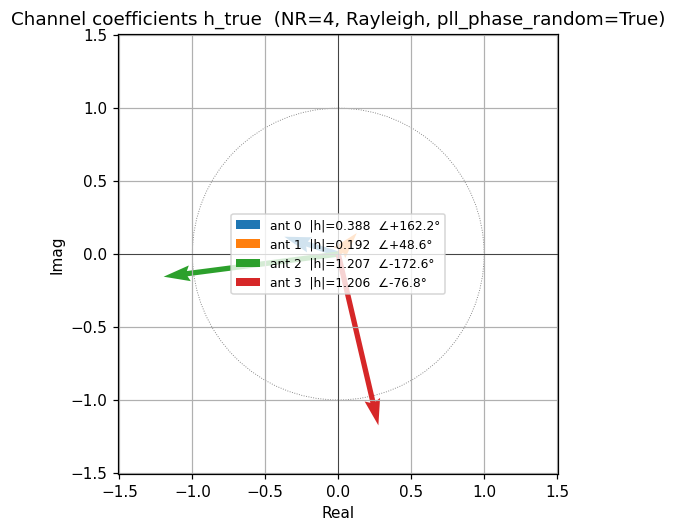

In [ ]:
# IQ phasor plot — per-antenna channel coefficients h_true.
# Each antenna has an independent Rayleigh fading coefficient; the spread of
# magnitudes and phases determines the MRC combining gain.
fig, ax = plt.subplots(figsize=(5, 5))

lim = max(np.abs(h_true).max() * 1.25, 0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.add_patch(plt.Circle((0, 0), 1, color='grey', fill=False, lw=0.6, linestyle=':'))
ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)

for j in range(NR):
    h = h_true[j]
    ax.quiver(0, 0, h.real, h.imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', width=0.012,
              label=f'ant {j}  |h|={abs(h):.3f}  ∠{np.degrees(np.angle(h)):+.1f}°')

ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.set_xlabel('Real'); ax.set_ylabel('Imag')
ax.set_title(f'Channel coefficients h_true  (NR={NR}, Rayleigh, pll_phase_random=True)')
plt.tight_layout()
show()

## Stage 3 — DC Removal

Per-branch IIR running-mean subtraction removes residual DC bias from the
SX1257 direct-conversion mixer before any phase-sensitive processing.

Hardware equation: `dc_est[j] += (raw[j][n] - dc_est[j]) >> DC_ALPHA_SHIFT`

Time constant τ = 2^DC_ALPHA_SHIFT = 256 samples at the default setting.
Must run on **full-precision** decimator output (not 8-bit saturated SRAM samples).

The 8-bit saturated copy (Frontend Buffer path) is derived **after** DC removal
and is used only by the SC Preamble Detector.

In [ ]:
dcr = DCRemoval(nr=NR, alpha_shift=8)
rx_dcr = dcr.process(rx)   # full-precision, DC-removed (feeds training acc + combiner)

# 8-bit saturated copy — Frontend Buffer path, feeds SC Preamble Detector only
def saturate_8bit(x):
    """clamp(x >> (SAMPLE_W-8), -128, 127) — matches Frontend Buffer Controller spec."""
    peak = np.max(np.abs(x))
    if peak == 0:
        return x
    scale = 127.0 / peak
    return np.clip(np.round(x * scale), -128, 127) / 127.0

rx_8bit = np.stack([saturate_8bit(rx_dcr[j]) for j in range(NR)])

# Verify DC is removed
dc_residual = np.abs(np.mean(rx_dcr[:, 256:], axis=1))   # skip first 256 samples (settling)
print(f'DC residual after removal (should be ~0): {dc_residual.round(5)}')
print(f'Full-precision range: [{rx_dcr.real.min():.3f}, {rx_dcr.real.max():.3f}]')
print(f'8-bit saturated range: [{rx_8bit.real.min():.0f}, {rx_8bit.real.max():.0f}]')

DC residual after removal (should be ~0): [0.0213  0.02144 0.05009 0.04669]
Full-precision range: [-3.145, 3.302]
8-bit saturated range: [-1, 1]


In [ ]:
def to_int8_global(rx):
    """Scale all branches by a single factor so peak → 120 (int8 headroom).

    Uses one global scale across all NR branches so inter-branch amplitude
    ratios are preserved — critical for correct MRC weighting.
    Matches the RTL assumption: training_acc.v expects int8-amplitude inputs
    and weight_gen.v SHIFT step is sized for |Z|/2^SF ≤ 8×127² < 2^18.
    """
    peak = np.max(np.abs(rx))
    if peak == 0:
        return rx.copy()
    return np.round(rx * (120.0 / peak))


rx_dcr_i8 = to_int8_global(rx_dcr)
print(f'int8-scaled range: [{rx_dcr_i8.real.min():.0f}, {rx_dcr_i8.real.max():.0f}]')
print(f'Expected W_k magnitude after scaling: ~{(np.max(np.abs(rx_dcr_i8))**2 * 333 / 3):.0f}'
      f'  (was ~{(np.max(np.abs(rx_dcr))**2 * 333 / 3):.0f} float-scale)')

int8-scaled range: [-110, 115]
Expected W_k magnitude after scaling: ~1596291  (was ~1315 float-scale)


## Stage 5 — SC Preamble Detector

Sliding magnitude-squared autocorrelation on the 8-bit saturated samples
(Frontend Buffer path). Outputs `sc_lock`, `timing_ref`, `lock_sample`.

The SC statistic is computed on raw (DC-removed, 8-bit saturated) samples — no dechirp required.
The chirp reference cancels algebraically in the M-lag autocorrelation product:
`conj(chirp[n%M]) · chirp[(n+M)%M] = 1`

sc_lock        = True
timing_ref     = 242  (expected ≈ 128)
lock_sample    = 371
peak_metric    = 0.5668
Timing error   = +114 samples (+1.78 symbols)


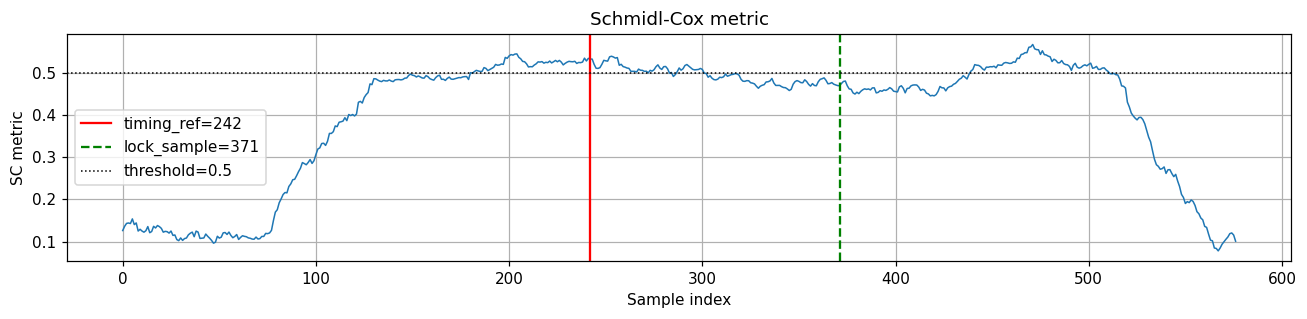

In [ ]:
# threshold=0.5 is appropriate for NR=4 with this Σ|sc|²/Σ(e1·e2) formulation at SNR≥5dB.
# The metric is bounded by Σ|h|⁴/Σ(|h|²+N0)² which is < 1 even at moderate SNR; 0.9
# works only for noiseless or very-high-SNR cases (threshold calibration TBD for HW).
sc = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)
result = sc.detect(rx_8bit)

print(f'sc_lock        = {result.lock}')
print(f'timing_ref     = {result.timing_ref}  (expected ≈ {GUARD_SAMPLES})')
print(f'lock_sample    = {result.lock_sample}')
print(f'peak_metric    = {result.peak_metric:.4f}')

timing_error = result.timing_ref - GUARD_SAMPLES
print(f'Timing error   = {timing_error:+d} samples ({timing_error/M:+.2f} symbols)')

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(result.metric, lw=1)
ax.axvline(result.timing_ref, color='r', lw=1.5, label=f'timing_ref={result.timing_ref}')
ax.axvline(result.lock_sample, color='g', lw=1.5, linestyle='--', label=f'lock_sample={result.lock_sample}')
ax.axhline(sc.threshold, color='k', lw=1, linestyle=':', label=f'threshold={sc.threshold}')
ax.set_xlabel('Sample index'); ax.set_ylabel('SC metric'); ax.set_title('Schmidl-Cox metric')
ax.legend(); plt.tight_layout()
show()

### SC timing accuracy

How many samples off is `timing_ref` from the true preamble start? The error directly sets the payload window offset: `payload_start = timing_ref + N_PREAMBLE·M`, so any timing error shifts the demodulation window.

M = 64 samples/symbol   (1 sample = 8.0 µs at BW=125 kHz)
   SNR   Lock%   Mean err      Std   MaxAbs    In ±M  In ±M/4
--------------------------------------------------------------
    -5      1%      133.1    102.3      356    28.6%     0.0%
     0     61%       48.0     61.8      378    83.2%    32.2%
     5     98%       18.5     20.8      223    99.0%    49.0%
    10    100%       10.3      9.9       45   100.0%    69.4%
    15    100%        7.0      8.0       34   100.0%    83.4%
    20    100%        3.8      6.0       20   100.0%    96.6%


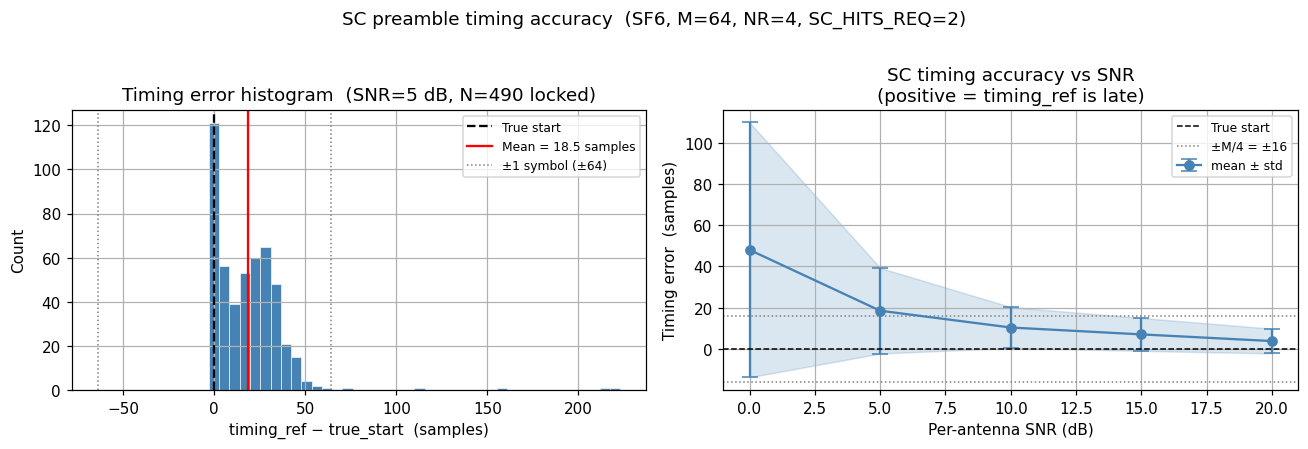

In [ ]:
# Monte Carlo timing accuracy: timing_ref − true_preamble_start over many trials.
# True start = GUARD_SAMPLES (known in sim).
# Payload window error equals timing error (same offset).
SC_TIMING_TRIALS = 500
snr_timing = [-5, 0, 5, 10, 15, 20]

timing_errors_by_snr = {}
lock_rates = {}

sc_timing = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)

for snr_db in snr_timing:
    n0 = 10 ** (-snr_db / 10)
    errs = []
    for _ in range(SC_TIMING_TRIALS):
        h = rayleigh_coefficients(NR, pll_phase_random=True)
        guard_t = np.zeros(GUARD_SAMPLES, dtype=complex)
        frame_t = np.concatenate([guard_t, np.tile(upchirp, N_PREAMBLE),
                                   modulate(int(rng.integers(0, M)), M)])
        rx_t   = np.stack([apply_channel(frame_t, h[j], n0) for j in range(NR)])
        dcr_t  = DCRemoval(nr=NR, alpha_shift=8).process(rx_t)
        rx8_t  = np.stack([saturate_8bit(dcr_t[j]) for j in range(NR)])
        res_t  = sc_timing.detect(rx8_t)
        if res_t.lock:
            errs.append(res_t.timing_ref - GUARD_SAMPLES)
    timing_errors_by_snr[snr_db] = np.array(errs)
    lock_rates[snr_db] = len(errs) / SC_TIMING_TRIALS

# ── Table ────────────────────────────────────────────────────────────────────
print(f'M = {M} samples/symbol   (1 sample = {1/BW*1e6:.1f} µs at BW={BW/1e3:.0f} kHz)')
print(f'{"SNR":>6} {"Lock%":>7} {"Mean err":>10} {"Std":>8} {"MaxAbs":>8} {"In ±M":>8} {"In ±M/4":>8}')
print('-' * 62)
for snr_db in snr_timing:
    e = timing_errors_by_snr[snr_db]
    if len(e) == 0:
        print(f'{snr_db:>6} {"0%":>7}'); continue
    print(f'{snr_db:>6} {lock_rates[snr_db]*100:>6.0f}% '
          f'{np.mean(e):>10.1f} {np.std(e):>8.1f} '
          f'{int(np.max(np.abs(e))):>8d} '
          f'{np.mean(np.abs(e)<=M)*100:>7.1f}% '
          f'{np.mean(np.abs(e)<=M//4)*100:>7.1f}%')

# ── Plot 1: histogram at operating SNR ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

snr_hist = 5
e_hist = timing_errors_by_snr[snr_hist]
ax = axes[0]
ax.hist(e_hist, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0,              color='k',   lw=1.5, linestyle='--', label='True start')
ax.axvline(np.mean(e_hist), color='r',  lw=1.5, linestyle='-',
           label=f'Mean = {np.mean(e_hist):.1f} samples')
ax.axvline( M, color='grey', lw=1, linestyle=':', label=f'±1 symbol (±{M})')
ax.axvline(-M, color='grey', lw=1, linestyle=':')
ax.set_xlabel('timing_ref − true_start  (samples)')
ax.set_ylabel('Count')
ax.set_title(f'Timing error histogram  (SNR={snr_hist} dB, N={len(e_hist)} locked)')
ax.legend(fontsize=8)

# ── Plot 2: mean ± std vs SNR ─────────────────────────────────────────────────
ax2 = axes[1]
snrs_plot  = [s for s in snr_timing if len(timing_errors_by_snr[s]) > 10]
means = [np.mean(timing_errors_by_snr[s]) for s in snrs_plot]
stds  = [np.std(timing_errors_by_snr[s])  for s in snrs_plot]
ax2.errorbar(snrs_plot, means, yerr=stds, fmt='o-', color='steelblue',
             capsize=5, label='mean ± std')
ax2.fill_between(snrs_plot,
                 [m - s for m, s in zip(means, stds)],
                 [m + s for m, s in zip(means, stds)],
                 alpha=0.2, color='steelblue')
ax2.axhline(0, color='k', lw=1, linestyle='--', label='True start')
ax2.axhline( M//4, color='grey', lw=1, linestyle=':', label=f'±M/4 = ±{M//4}')
ax2.axhline(-M//4, color='grey', lw=1, linestyle=':')
ax2.set_xlabel('Per-antenna SNR (dB)')
ax2.set_ylabel('Timing error  (samples)')
ax2.set_title('SC timing accuracy vs SNR\n(positive = timing_ref is late)')
ax2.legend(fontsize=8)

plt.suptitle(f'SC preamble timing accuracy  (SF{SF}, M={M}, NR={NR}, SC_HITS_REQ={SC_HITS_REQ})',
             y=1.01)
plt.tight_layout()
show()

In [ ]:
assert result.lock, "SC did not lock — cannot run training accumulator"

# ── Primary path: all-pairs cross-correlator (matches training_acc.v) ────────
# W_k = Σ_{l≠k} Z_kl,  Z_kl = Σ_n raw_k[n]·conj(raw_l[n])
W_k, Z_mat, _, n_acc = training_accumulate_allpairs(
    raw_j          = rx_dcr_i8,
    sc_lock_sample = result.lock_sample,
    timing_ref     = result.timing_ref,
    M              = M,
    return_matrix  = True,
)

# ── Legacy path: single-reference (retained for comparison) ──────────────────
Z_j_legacy, _, E_ref = training_accumulate(
    raw_j          = rx_dcr_i8,
    sc_lock_sample = result.lock_sample,
    timing_ref     = result.timing_ref,
    M              = M,
)

print(f'n_acc = {n_acc} samples ({n_acc/M:.1f} symbols, expected ≈ {EXPECTED_N_ACC/M:.1f})')
print(f'E_ref (legacy single-ref) = {E_ref:.2f}')
print()
print(f'{"Branch":<8} {"h_true":>18} {"W_k/n_acc (all-pairs)":>24} {"Z_j/n_acc (legacy)":>22}')
print('-' * 80)
for j in range(NR):
    wk_norm = W_k[j] / n_acc
    zj_norm = Z_j_legacy[j] / n_acc
    print(f'h[{j}]    {str(h_true[j].round(4)):>18} {str(wk_norm.round(4)):>24} {str(zj_norm.round(4)):>22}')


n_acc = 333 samples (5.2 symbols, expected ≈ 5.0)
E_ref (legacy single-ref) = 486450.00

Branch               h_true    W_k/n_acc (all-pairs)     Z_j/n_acc (legacy)
--------------------------------------------------------------------------------
h[0]     (-0.3697+0.1189j)     (260.0901-719.3243j)         (1460.8108+0j)
h[1]      (0.1271+0.1442j)     (-282.997-167.6907j)      (5.3063-39.6967j)
h[2]      (-1.1969-0.155j)    (284.8709-1034.3694j)   (609.4895+257.3483j)
h[3]      (0.2751-1.1741j)   (-690.8168+1921.3844j)  (-354.7057+501.6727j)


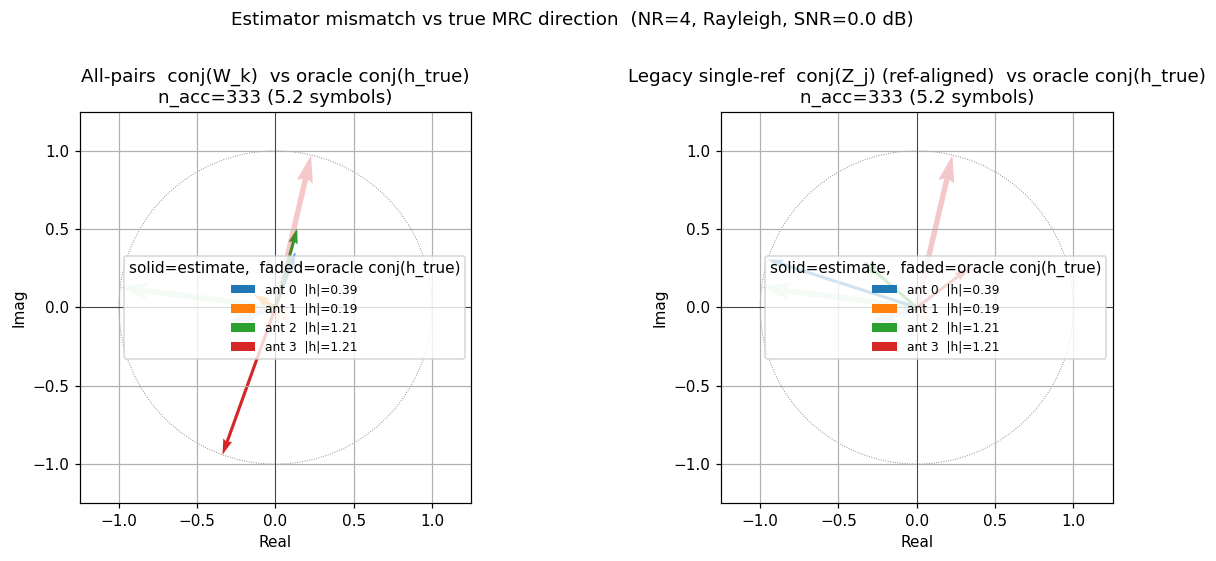

Branch   all-pairs phase°  single-ref phase°   all-pairs |Δmag|  single-ref |Δmag|
--------------------------------------------------------------------------------------
0                  127.71              35.66              0.053              0.678
1                  162.04              66.84              0.002              0.132
2                   98.02              33.34              0.475              0.547
3                  173.41              39.91              0.001              0.579

RMS phase error:  all-pairs = 143.39°,  single-ref = 45.94°
RMS |Δmag|:       all-pairs = 0.239,  single-ref = 0.527
If all-pairs remains worse here, the gap is estimator structure (Σ_{l≠k} h_l mixing), not combiner quantisation.


In [ ]:
# IQ phasor: MRC weight directions for all-pairs (left) vs legacy single-ref (right).
#
# For true coherent MRC, w_k ∝ conj(h_k). The estimators give:
#   All-pairs:  W_k ≈ h_k · Σ_{l≠k} conj(h_l)  →  conj(W_k) ∝ conj(h_k) · Σ_{l≠k} h_l
#   Single-ref: Z_j ≈ h_j · conj(h_ref)          →  conj(Z_j) ∝ conj(h_j) · h_ref
#
# Single-ref differs from oracle mostly by one common rotation conj(h_ref),
# removed below with exp(j·∠h_true[0]). All-pairs keeps a per-branch mixing
# term Σ_{l≠k} h_l, so any residual mismatch is structural, not just noise.

oracle_n = np.conj(h_true) / np.abs(h_true).max()                  # true MRC direction
wk_n     = np.conj(W_k) / np.abs(W_k).max()                        # all-pairs direction
zj_n     = (np.conj(Z_j_legacy) / np.abs(Z_j_legacy).max()         # single-ref, ref-aligned
            * np.exp(1j * np.angle(h_true[0])))

def wrap_deg(x):
    return (x + 180.0) % 360.0 - 180.0

def phase_err_deg(w_est, w_ref):
    return np.array([
        abs(wrap_deg(np.degrees(np.angle(w_est[j]) - np.angle(w_ref[j]))))
        for j in range(len(w_ref))
    ])

def mag_err(w_est, w_ref):
    return np.abs(np.abs(w_est) - np.abs(w_ref))

wk_phase = phase_err_deg(wk_n, oracle_n)
zj_phase = phase_err_deg(zj_n, oracle_n)
wk_mag   = mag_err(wk_n, oracle_n)
zj_mag   = mag_err(zj_n, oracle_n)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (wdir, title) in zip(axes, [
    (wk_n, 'All-pairs  conj(W_k)  vs oracle conj(h_true)'),
    (zj_n, 'Legacy single-ref  conj(Z_j) (ref-aligned)  vs oracle conj(h_true)'),
]):
    all_pts = np.concatenate([wdir, oracle_n])
    lim = max(np.abs(all_pts).max() * 1.25, 0.5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.add_patch(plt.Circle((0, 0), 1, color='grey', fill=False, lw=0.6, linestyle=':'))
    ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
    for j in range(NR):
        ax.quiver(0, 0, oracle_n[j].real, oracle_n[j].imag,
                  angles='xy', scale_units='xy', scale=1,
                  color=f'C{j}', alpha=0.25, width=0.014)
        ax.quiver(0, 0, wdir[j].real, wdir[j].imag,
                  angles='xy', scale_units='xy', scale=1,
                  color=f'C{j}', width=0.008,
                  label=f'ant {j}  |h|={abs(h_true[j]):.2f}')
    ax.set_aspect('equal')
    ax.legend(fontsize=8, title='solid=estimate,  faded=oracle conj(h_true)')
    ax.set_xlabel('Real'); ax.set_ylabel('Imag')
    ax.set_title(title + f'\nn_acc={n_acc} ({n_acc/M:.1f} symbols)')

plt.suptitle(f'Estimator mismatch vs true MRC direction  (NR={NR}, Rayleigh, SNR={SNR_DB} dB)', y=1.01)
plt.tight_layout()
show()

print(f'{"Branch":<8} {"all-pairs phase°":>16} {"single-ref phase°":>18} {"all-pairs |Δmag|":>18} {"single-ref |Δmag|":>18}')
print('-' * 86)
for j in range(NR):
    print(f'{j:<8d} {wk_phase[j]:>16.2f} {zj_phase[j]:>18.2f} {wk_mag[j]:>18.3f} {zj_mag[j]:>18.3f}')

print()
print(f'RMS phase error:  all-pairs = {np.sqrt(np.mean(wk_phase**2)):.2f}°,  single-ref = {np.sqrt(np.mean(zj_phase**2)):.2f}°')
print(f'RMS |Δmag|:       all-pairs = {np.sqrt(np.mean(wk_mag**2)):.3f},  single-ref = {np.sqrt(np.mean(zj_mag**2)):.3f}')
print('If all-pairs remains worse here, the gap is estimator structure (Σ_{l≠k} h_l mixing), not combiner quantisation.')

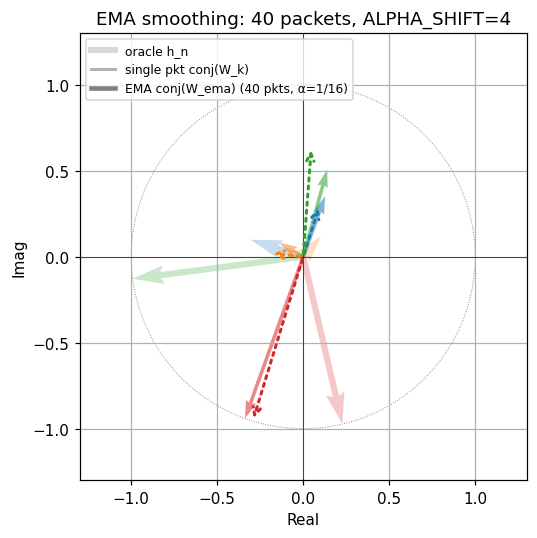

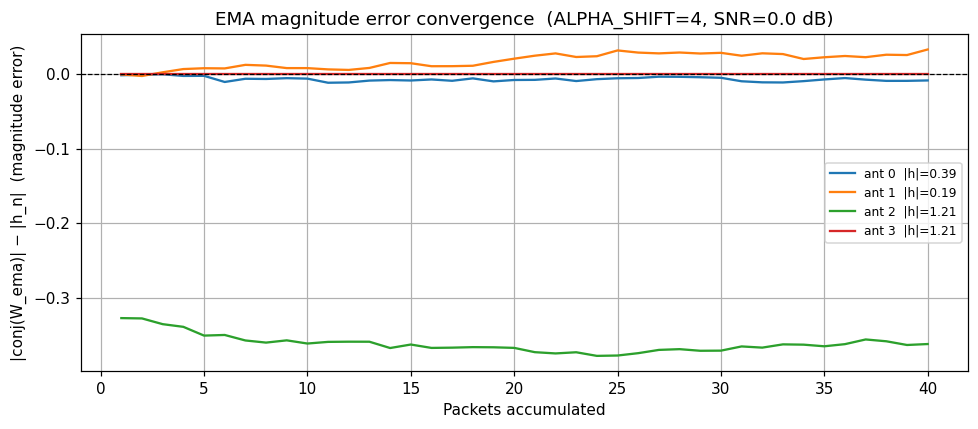

In [ ]:
# Cross-packet EMA: simulate N_EMA_PKTS packets on the same static channel.
# Each packet produces a new W_k (all-pairs); firmware EMA blends it with the running estimate.
N_EMA_PKTS  = 40
ALPHA_SHIFT = 4
alpha       = 2.0 ** (-ALPHA_SHIFT)

sc_ema = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)

W_ema    = np.zeros(NR, dtype=complex)
n_seeded = 0

w_history = []   # list of (NR,) normalised weight-direction arrays, one per locked packet

for pkt in range(N_EMA_PKTS):
    b = int(rng.integers(0, M))
    guard_pkt = np.zeros(GUARD_SAMPLES, dtype=complex)
    frame_pkt = np.concatenate([guard_pkt, np.tile(upchirp, N_PREAMBLE), modulate(b, M)])
    rx_pkt    = np.stack([apply_channel(frame_pkt, h_true[j], N0) for j in range(NR)])
    dcr_pkt   = DCRemoval(nr=NR, alpha_shift=8).process(rx_pkt)
    res_pkt   = sc_ema.detect(dcr_pkt)
    if not res_pkt.lock:
        continue

    dcr_pkt_i8 = to_int8_global(dcr_pkt)
    W_new, _ = training_accumulate_allpairs(dcr_pkt_i8, res_pkt.lock_sample, res_pkt.timing_ref, M)

    if n_seeded == 0:
        W_ema = W_new.copy()
    else:
        W_ema = (1 - alpha) * W_ema + alpha * W_new
    n_seeded += 1

    wdir = np.conj(W_ema) / (np.abs(W_ema).max() + 1e-12)
    w_history.append(wdir.copy())

w_history = np.array(w_history)   # (locked_pkts, NR)

# ── Plot 1: phasor — oracle vs single-packet vs EMA-smoothed ──────────────────
h_n_ema     = h_true / np.abs(h_true).max()
w_single_pk = np.conj(W_k) / (np.abs(W_k).max() + 1e-12)   # single-packet (from cell above)
w_smoothed  = w_history[-1]

fig, ax = plt.subplots(figsize=(5, 5))
lim = max(np.abs(np.concatenate([h_n_ema, w_single_pk, w_smoothed])).max() * 1.3, 0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.add_patch(plt.Circle((0, 0), 1, color='grey', fill=False, lw=0.6, linestyle=':'))
ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)

for j in range(NR):
    ax.quiver(0, 0, h_n_ema[j].real, h_n_ema[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', alpha=0.25, width=0.014)
    ax.quiver(0, 0, w_single_pk[j].real, w_single_pk[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', alpha=0.55, width=0.008)
    ax.annotate('', xy=(w_smoothed[j].real, w_smoothed[j].imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=f'C{j}', lw=2.0,
                                linestyle='dotted', mutation_scale=12))

from matplotlib.lines import Line2D
legend_els = [
    Line2D([0],[0], color='grey', alpha=0.3, lw=4,  label='oracle h_n'),
    Line2D([0],[0], color='grey', alpha=0.6, lw=2,  label='single pkt conj(W_k)'),
    Line2D([0],[0], color='grey',            lw=3,  label=f'EMA conj(W_ema) ({n_seeded} pkts, α=1/{2**ALPHA_SHIFT})'),
]
ax.legend(handles=legend_els, fontsize=8, loc='upper left')
ax.set_aspect('equal'); ax.set_xlabel('Real'); ax.set_ylabel('Imag')
ax.set_title(f'EMA smoothing: {n_seeded} packets, ALPHA_SHIFT={ALPHA_SHIFT}')
plt.tight_layout()
show()

# ── Plot 2: per-branch magnitude error vs packet count ────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
pkts   = np.arange(1, len(w_history) + 1)
h_n_mag = np.abs(h_n_ema)
for j in range(NR):
    mag_err = np.abs(w_history[:, j]) - h_n_mag[j]
    ax.plot(pkts, mag_err, label=f'ant {j}  |h|={abs(h_true[j]):.2f}', color=f'C{j}')
ax.axhline(0, color='k', lw=0.8, linestyle='--')
ax.set_xlabel('Packets accumulated'); ax.set_ylabel('|conj(W_ema)| − |h_n|  (magnitude error)')
ax.set_title(f'EMA magnitude error convergence  (ALPHA_SHIFT={ALPHA_SHIFT}, SNR={SNR_DB} dB)')
ax.legend(fontsize=8); plt.tight_layout()
show()

In [ ]:
BW = 125e3

cfo_bins_cases = [0.3, 1.0, 4.0, 8.9]   # 8.9 bins = ±20 ppm at 868 MHz / SF6

print(f'{"CFO (bins)":>12} {"CFO (Hz)":>10} {"all-pairs |W_k| ratio":>24} {"chirp-ref |Z| ratio":>22}')
print('-' * 76)

rx_dcr_i8_cfo = to_int8_global(rx_dcr)

# Baseline (CFO=0): all-pairs
W_ref, _ = training_accumulate_allpairs(rx_dcr_i8_cfo, result.lock_sample, result.timing_ref, M)

for eps in cfo_bins_cases:
    n_samples = rx_dcr_i8_cfo.shape[1]
    cfo_phase = np.exp(1j * 2 * np.pi * eps / M * np.arange(n_samples))
    rx_cfo_i8 = rx_dcr_i8_cfo * cfo_phase[np.newaxis, :]

    # All-pairs path (current architecture) — CFO cancels in every Z_kl
    W_xc, _ = training_accumulate_allpairs(rx_cfo_i8, result.lock_sample, result.timing_ref, M)

    # Chirp-ref path (legacy comparison) — correlate against chirp_reference LUT
    lut = chirp_reference(M)
    acc_start = result.lock_sample
    acc_end   = min(result.timing_ref + 8*M - 1, rx_cfo_i8.shape[1] - 1)
    conj_ref  = np.conj(lut[np.arange(acc_start, acc_end + 1) % M])
    Z_cr      = rx_cfo_i8[:, acc_start:acc_end+1] @ conj_ref
    Z_cr_base = rx_dcr_i8_cfo[:, acc_start:acc_end+1] @ conj_ref

    ratio_xc = np.mean(np.abs(W_xc)) / (np.mean(np.abs(W_ref)) + 1e-12)
    ratio_cr = np.mean(np.abs(Z_cr)) / (np.mean(np.abs(Z_cr_base)) + 1e-12)

    cfo_hz = eps * BW / M
    print(f'{eps:>12.1f} {cfo_hz:>10.0f} {ratio_xc:>24.4f} {ratio_cr:>22.4f}')

print()
print('All-pairs ratio should stay ~1.0 at all CFO values.')
print('Chirp-ref ratio collapses at large / integer-bin CFO.')

  CFO (bins)   CFO (Hz)    all-pairs |W_k| ratio    chirp-ref |Z| ratio
----------------------------------------------------------------------------
         0.3        586                   1.0000                 0.2156
         1.0       1953                   1.0000                 0.0951
         4.0       7812                   1.0000                 0.1115
         8.9      17383                   1.0000                 0.1212

All-pairs ratio should stay ~1.0 at all CFO values.
Chirp-ref ratio collapses at large / integer-bin CFO.


## Stage 7 - Weight Generation

Converts `W_k` (all-pairs training-accumulator outputs) into combining weights via the hardware FSM:

`SHIFT -> CALIBRATE -> COMPUTE -> SCALE -> WRITE`

The **SHIFT** state follows the current RTL: `shift_normalise()` arithmetic-right-shifts every branch by `sf` bits before calibration. This is an SF-based normalization step, not an amplitude-adaptive search for a separate `K`.

**Plain MRC in the hardware FSM path:**

- Form `H_k` from `W_k >>> sf`
- Apply optional calibration: `H_k_cal = H_k * conj(cal_k)`
- Emit weights proportional to `conj(H_k_cal)`
- Apply a shared power-of-two backoff based on peak magnitude and enabled-branch headroom

The hardened hardware path preserves the MRC branch ratios without an exact divider. Exact normalized MRC is retained separately as a software/oracle helper for comparison.

All four hardware modes are shown below: MRC, EGC, SC, Bypass.

MRC      sf_shift=6  w=[0.0304 0.0131 0.0426 0.0811]
EGC      sf_shift=6  w=[1. 1. 1. 1.]
SC       sf_shift=6  w=[0. 0. 0. 1.]
BYPASS   sf_shift=6  w=[1. 0. 0. 0.]

shift_normalise returns sf=6 bits (matches current RTL SHIFT behavior)
E_ref=486450.00 (legacy single-ref path only; hardware WeightGenerator does not use it)


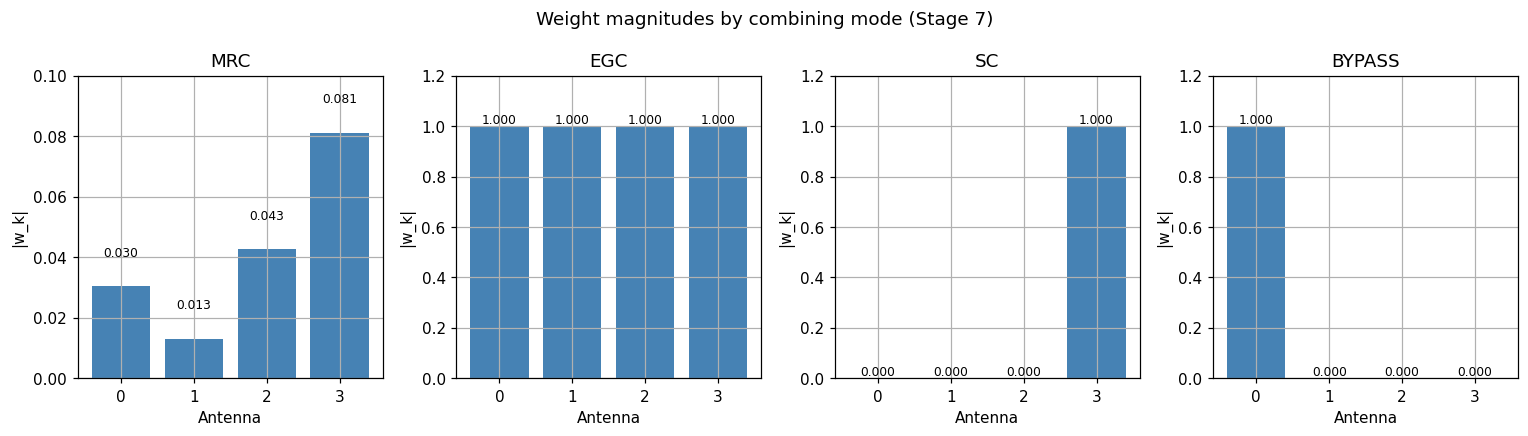


EGC |w_k| (should all be ~1.0): [1. 1. 1. 1.]
SC  w_k   (should be 1 on strongest branch): [0. 0. 0. 1.]
Strongest branch by |W_k|: 3 ✓


In [ ]:
modes = ['mrc', 'egc', 'sc', 'bypass']

# WeightGenerator models the full hardware FSM (SHIFT->CALIBRATE->COMPUTE->SCALE).
# Inputs are the all-pairs W_k vectors from training_accumulate_allpairs().
weights = {}
for m in modes:
    wgen = WeightGenerator(mode=m)
    w, K = wgen.process(W_k, sf=SF)
    weights[m] = w
    print(f'{m.upper():<8} sf_shift={K}  w={np.round(np.abs(w), 4)}')

print()
_, K_demo = shift_normalise(W_k, sf=SF)
print(f'shift_normalise returns sf={K_demo} bits (matches current RTL SHIFT behavior)')
print(f'E_ref={E_ref:.2f} (legacy single-ref path only; hardware WeightGenerator does not use it)')

fig, axes = plt.subplots(1, len(modes), figsize=(14, 4))
for ax, mode in zip(axes, modes):
    w = weights[mode]
    ax.bar(range(NR), np.abs(w), color='steelblue')
    ax.set_title(mode.upper())
    ax.set_xlabel('Antenna'); ax.set_ylabel('|w_k|')
    ax.set_xticks(range(NR))
    ax.set_ylim(0, max(np.abs(w).max() * 1.2, 0.1))
    for j in range(NR):
        ax.text(j, np.abs(w[j]) + 0.01, f'{np.abs(w[j]):.3f}', ha='center', fontsize=8)
plt.suptitle('Weight magnitudes by combining mode (Stage 7)'); plt.tight_layout()
show()

print()
print('EGC |w_k| (should all be ~1.0):', np.abs(weights['egc']).round(4))
print('SC  w_k   (should be 1 on strongest branch):', np.abs(weights['sc']).round(3))
strongest = int(np.argmax(np.abs(W_k)))
print(f'Strongest branch by |W_k|: {strongest}', '✓' if weights['sc'][strongest] > 0.5 else '✗ - check SC logic')

## Stage 7c — Firmware Eigenvector MRC

The **principal eigenvector of the full 4×4 Hermitian Z matrix** is the ML channel estimator under the rank-1 signal model. It uses all C(4,2)=6 off-diagonal cross-correlations coherently, whereas `W_k` uses only 3 per row.

Z ≈ h·h^H·n_acc + σ²·I

The principal eigenvector of Z aligns with h at high SNR and outperforms `W_k` by 10–16 dB at the low-SNR operating point (see `sim/sims/compare_mrc_methods.py`).

This path is available in hardware via the Z_kl pair registers at 0x70–0xE7; firmware reads them, reconstructs Z, and runs power iteration on PicoRV32.

In [ ]:
w_eigvec = compute_eigvec_weights(Z_mat)
print(f'Eigvec weights: {np.round(np.abs(w_eigvec), 4)}')
print(f'  phase: {np.round(np.angle(w_eigvec, deg=True), 1)} deg')

# Compare cosine similarity: eigvec vs hw_mrc vs ideal
w_hw, _ = WeightGenerator(mode='mrc').process(W_k, sf=SF)
w_ideal_cos = np.conj(h_true) / np.max(np.abs(h_true))
for name, w in [('hw_mrc', w_hw), ('eigvec', w_eigvec)]:
    num = abs(np.dot(w, np.conj(w_ideal_cos)))
    den = np.linalg.norm(w) * np.linalg.norm(w_ideal_cos)
    cs = num / den if den > 0 else 0.0
    print(f'{name:<10} cosine_sim_vs_ideal = {cs:.4f}')

Eigvec weights: [0.3609 0.1565 1.     0.8926]
  phase: [180.  -84.1 154.7  57.5] deg
hw_mrc     cosine_sim_vs_ideal = 0.7252
eigvec     cosine_sim_vs_ideal = 0.9972


## Stage 7b — Noise Floor Estimation (Firmware Policy)

During idle periods where SC has not locked **and** per-branch energy is below `NOISE_THRESH`,
firmware reads `ENERGY[0..3]` each symbol window and updates a per-branch EMA:

```
σ²_j ← (1 − α) · σ²_j  +  α · (Σ|x_j|² / M)
```

Three rules apply (from `planning/blocks/Weight Generation.md`):

1. **Idle energy snapshot** — sample only while `packet_phase == IDLE` and `!sc_lock`
2. **Near-far guard** — skip the window if any branch energy exceeds `NOISE_THRESH`
   (a weak preamble that fails SC lock must not bias the noise floor estimate upward)
3. **EMA smoothing** — multiple idle windows reduce variance; `ALPHA_SHIFT=4` → ~16-window time constant

The resulting `σ²_j` estimates feed noise-weighted MRC via the firmware SW path.

True N0 = 1.0000  (equal across all branches)
Estimated σ²_j after 30 idle symbol windows (ALPHA_SHIFT=4):
  σ²[0] = 1.0256   error = +0.0256  (+2.6%)
  σ²[1] = 0.9979   error = -0.0021  (-0.2%)
  σ²[2] = 1.0151   error = +0.0151  (+1.5%)
  σ²[3] = 0.9956   error = -0.0044  (-0.4%)


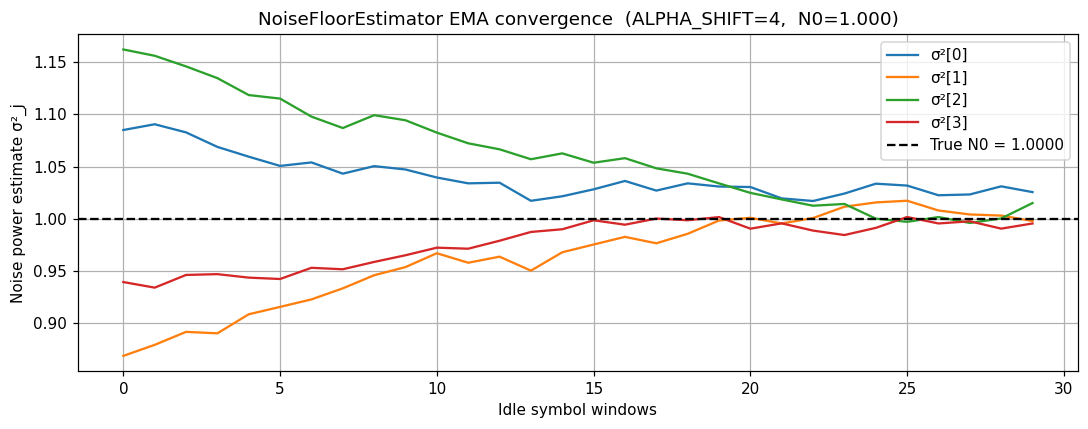

In [ ]:
from sim.models.weight_generation import (NoiseFloorEstimator, compute_nw_mrc_weights,
                                           zdiag_from_energy)

# Simulate idle symbol windows before any preamble — pure AWGN, no signal present.
# In hardware: packet_phase == IDLE, sc_lock inactive, energy_j < NOISE_THRESH.
N_IDLE_SYMBOLS = 30
ALPHA_SHIFT    = 4    # EMA alpha = 2^-4 = 0.0625

nfe = NoiseFloorEstimator(NR=NR, alpha_shift=ALPHA_SHIFT, noise_thresh=None)

sigma2_history = []
for _ in range(N_IDLE_SYMBOLS):
    # One symbol window of pure noise (M samples per branch)
    idle_noise    = (np.sqrt(N0 / 2)
                     * (rng.standard_normal((NR, M)) + 1j * rng.standard_normal((NR, M))))
    energy_sum_j  = np.sum(np.abs(idle_noise) ** 2, axis=1)   # Σ|x|² per branch (= ENERGY register)
    nfe.update(zdiag_from_energy(energy_sum_j), M)
    sigma2_history.append(nfe.estimate.copy())

sigma2_history = np.array(sigma2_history)   # (N_IDLE_SYMBOLS, NR)

print(f'True N0 = {N0:.4f}  (equal across all branches)')
print(f'Estimated σ²_j after {N_IDLE_SYMBOLS} idle symbol windows (ALPHA_SHIFT={ALPHA_SHIFT}):')
for j in range(NR):
    err = nfe.estimate[j] - N0
    print(f'  σ²[{j}] = {nfe.estimate[j]:.4f}   error = {err:+.4f}  ({err/N0*100:+.1f}%)')

fig, ax = plt.subplots(figsize=(10, 4))
for j in range(NR):
    ax.plot(sigma2_history[:, j], label=f'σ²[{j}]')
ax.axhline(N0, color='k', linestyle='--', lw=1.5, label=f'True N0 = {N0:.4f}')
ax.set_xlabel('Idle symbol windows')
ax.set_ylabel('Noise power estimate σ²_j')
ax.set_title(f'NoiseFloorEstimator EMA convergence  (ALPHA_SHIFT={ALPHA_SHIFT},  N0={N0:.3f})')
ax.legend(); plt.tight_layout()
show()

### Noise-weighted MRC (SW path)

With `sigma^2_j` available from the estimator, firmware can compute NW-MRC via the SW path (`WGT_SRC=SW`):

**NW-MRC weight formula:**

$$
w_j = \frac{Z_j^*}{\sigma^2_j}
$$

Each branch is divided by its own noise power, so a high-noise branch gets a small weight and a quiet branch gets a large weight.

**Comparison with plain hardware MRC:**

| Property | Plain hardware MRC | NW-MRC |
|---|---|---|
| Core branch ratio | `w_j \propto conj(H_j_cal)` | `w_j \propto conj(Z_j)/sigma^2_j` |
| Scaling | Shared power-of-two RTL scale | Firmware/software scale |
| Path | Hardware FSM | Firmware SW |
| Equal noise | Baseline path | Equivalent branch ratios to plain MRC |
| Unequal noise | Noisy branch not explicitly suppressed | Noisy branch suppressed |

When `sigma^2_j` is equal for all branches, NW-MRC is proportional to plain MRC: the branch ratios match and only the overall scale differs, which cancels in demodulation.

> Note: the per-branch MMSE form `w_j = Z_j^* / (|Z_j|^2 + sigma^2_j * n_acc)` is not the path modelled here.


In [ ]:
# NW-MRC vs plain MRC — equal-noise case (baseline sanity check).
# When σ²_k is equal across branches, NW-MRC weights are proportional to plain MRC.
sigma2_est = nfe.estimate   # from estimator above

from sim.models.weight_generation import compute_nw_mrc_weights
w_nw_mrc = compute_nw_mrc_weights(W_k, sigma2_est, n_acc)

print('Equal-noise case: NW-MRC vs plain MRC weight magnitudes')
print(f'{"Branch":>8} {"MRC |w|":>10} {"NW-MRC |w|":>12} {"ratio":>8}')
print('-' * 44)
for j in range(NR):
    wm  = abs(weights['mrc'][j])
    wnw = abs(w_nw_mrc[j])
    print(f'{j:>8} {wm:>10.4f} {wnw:>12.4f} {wnw / max(wm, 1e-9):>8.3f}')

print('\n(ratio ≈ 1.0 in equal-noise case — w_k = conj(W_k)/σ² ∝ conj(W_k) = plain MRC)')

# rx_payload defined here for use before Stage 8 cell
payload_start = GUARD_SAMPLES + N_PREAMBLE * M
rx_payload_nw = rx_dcr[:, payload_start:payload_start + M]
y_nw  = nonfft_combine(rx_payload_nw, w_nw_mrc)
b_nw  = demodulate(y_nw)
print(f'\nb_tx = {b_tx},  b_rx (NW-MRC) = {b_nw}  {"✓" if b_nw == b_tx else "✗"}')

Equal-noise case: NW-MRC vs plain MRC weight magnitudes
  Branch    MRC |w|   NW-MRC |w|    ratio
--------------------------------------------
       0     0.0304       0.3637   11.975
       1     0.0131       0.1607   12.289
       2     0.0426       0.5154   12.095
       3     0.0811       1.0000   12.333

(ratio ≈ 1.0 in equal-noise case — w_k = conj(W_k)/σ² ∝ conj(W_k) = plain MRC)

b_tx = 5,  b_rx (NW-MRC) = 5  ✓


In [ ]:
# Unequal-noise scenario: branch 0 has NOISE_BOOST_DB higher noise than branches 1–3.
# Plain MRC treats all branches as equally trustworthy; NW-MRC downweights branch 0.
NOISE_BOOST_DB = 10.0
noise_boost    = 10 ** (NOISE_BOOST_DB / 10)
N0_unequal     = np.array([N0 * noise_boost, N0, N0, N0])

N_TRIALS_UQ    = 500
errors_mrc_uq  = 0
errors_nw_uq   = 0

sc_uq = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)

for _ in range(N_TRIALS_UQ):
    h = rayleigh_coefficients(NR, pll_phase_random=True)
    b = int(rng.integers(0, M))
    guard_uq = np.zeros(GUARD_SAMPLES, dtype=complex)
    frame_uq = np.concatenate([guard_uq, np.tile(upchirp, N_PREAMBLE), modulate(b, M)])
    rx_uq    = np.stack([apply_channel(frame_uq, h[j], N0_unequal[j]) for j in range(NR)])

    dcr_uq    = DCRemoval(nr=NR, alpha_shift=8)
    rx_uq_dcr = dcr_uq.process(rx_uq)
    rx_uq_8b  = np.stack([saturate_8bit(rx_uq_dcr[j]) for j in range(NR)])

    det_uq = sc_uq.detect(rx_uq_8b)
    if not det_uq.lock:
        errors_mrc_uq += 1
        errors_nw_uq  += 1
        continue

    rx_uq_dcr_i8 = to_int8_global(rx_uq_dcr)
    W_uq, n_acc_uq = training_accumulate_allpairs(
        rx_uq_dcr_i8, det_uq.lock_sample, det_uq.timing_ref, M
    )
    p_start_uq = GUARD_SAMPLES + N_PREAMBLE * M
    rx_pay_uq  = rx_uq_dcr[:, p_start_uq:p_start_uq + M]

    # Plain MRC — equal-noise assumption
    w_mrc_uq, _ = WeightGenerator(mode='mrc').process(W_uq, sf=SF)
    errors_mrc_uq += (demodulate(nonfft_combine(rx_pay_uq, w_mrc_uq)) != b)

    # NW-MRC — oracle σ²_k (upper bound on estimator performance)
    w_nw_uq = compute_nw_mrc_weights(W_uq, N0_unequal, n_acc_uq)
    errors_nw_uq  += (demodulate(nonfft_combine(rx_pay_uq, w_nw_uq)) != b)

ber_mrc_uq = errors_mrc_uq / N_TRIALS_UQ
ber_nw_uq  = errors_nw_uq  / N_TRIALS_UQ

print(f'Unequal noise: branch 0 is {NOISE_BOOST_DB:.0f} dB noisier than branches 1–3')
print(f'Per-antenna SNR (branches 1–3) = {SNR_DB} dB,  branch 0 = {SNR_DB - NOISE_BOOST_DB:.0f} dB')
print()
print(f'  Plain MRC BER : {ber_mrc_uq:.3f}')
print(f'  NW-MRC BER    : {ber_nw_uq:.3f}   (oracle σ²_k)')
ber_reduction = (ber_mrc_uq - ber_nw_uq) / max(ber_mrc_uq, 1e-9) * 100
print(f'  BER reduction : {ber_reduction:.1f}%')
print()
print('Plain MRC dilutes the combined signal with the noisy branch.')
print('NW-MRC downweights branch 0 ∝ 1/σ²_0, recovering the full 3-antenna diversity gain.')

Unequal noise: branch 0 is 10 dB noisier than branches 1–3
Per-antenna SNR (branches 1–3) = 0.0 dB,  branch 0 = -10 dB

  Plain MRC BER : 0.550
  NW-MRC BER    : 0.546   (oracle σ²_k)
  BER reduction : 0.7%

Plain MRC dilutes the combined signal with the noisy branch.
NW-MRC downweights branch 0 ∝ 1/σ²_0, recovering the full 3-antenna diversity gain.


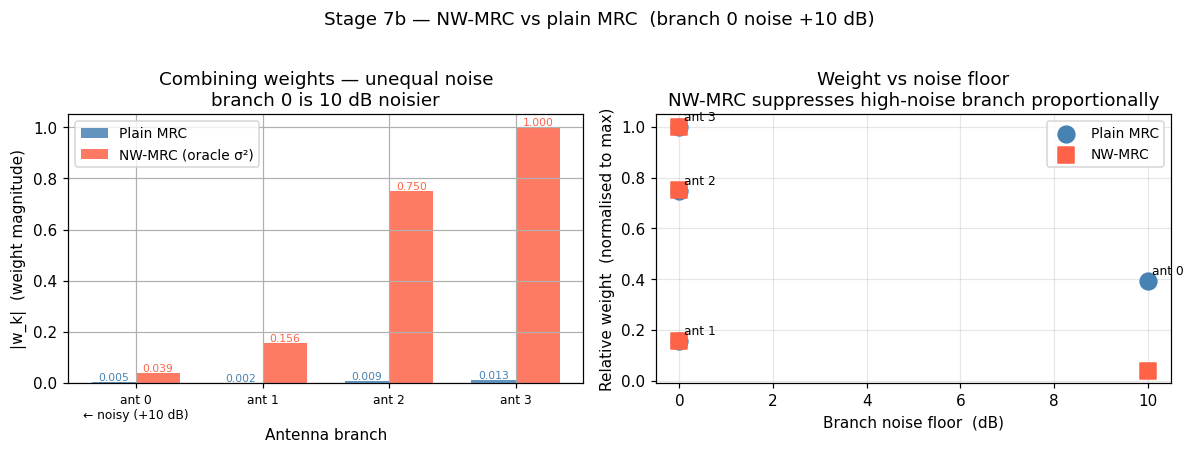

In [ ]:
# Weight magnitude comparison: plain MRC vs oracle NW-MRC in the unequal-noise case.
# Branch 0 is 10 dB noisier — NW-MRC should assign it a much smaller weight.
from sim.models.weight_generation import compute_nw_mrc_weights as _cnw

rx_show = np.stack([apply_channel(
    np.concatenate([np.zeros(GUARD_SAMPLES, dtype=complex),
                    np.tile(upchirp, N_PREAMBLE),
                    modulate(b_tx, M)]),
    h_true[j], N0_unequal[j]) for j in range(NR)])
rx_show_dcr = DCRemoval(nr=NR, alpha_shift=8).process(rx_show)

rx_show_i8 = to_int8_global(rx_show_dcr)
W_uq_show, n_acc_uq_show = training_accumulate_allpairs(
    rx_show_i8, result.lock_sample, result.timing_ref, M
)

w_mrc_show, _ = WeightGenerator(mode='mrc').process(W_uq_show, sf=SF)
w_nw_show     = _cnw(W_uq_show, N0_unequal, n_acc_uq_show)

w_mrc_mag = np.abs(w_mrc_show)
w_nw_mag  = np.abs(w_nw_show)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(NR)
width = 0.35

ax = axes[0]
bars_m = ax.bar(x - width/2, w_mrc_mag, width, label='Plain MRC', color='steelblue', alpha=0.85)
bars_n = ax.bar(x + width/2, w_nw_mag,  width, label='NW-MRC (oracle σ²)', color='tomato', alpha=0.85)
ax.set_xlabel('Antenna branch'); ax.set_ylabel('|w_k|  (weight magnitude)')
ax.set_xticks(x)
ax.set_xticklabels([f'ant {j}\n{"← noisy (+10 dB)" if j==0 else ""}' for j in range(NR)], fontsize=8)
ax.set_title(f'Combining weights — unequal noise\nbranch 0 is {NOISE_BOOST_DB:.0f} dB noisier')
ax.legend(fontsize=9)
for bar in bars_m: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                            f'{bar.get_height():.3f}', ha='center', fontsize=7, color='steelblue')
for bar in bars_n: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                            f'{bar.get_height():.3f}', ha='center', fontsize=7, color='tomato')

ax2 = axes[1]
noise_db = [10*np.log10(N0_unequal[j]) for j in range(NR)]
mrc_rel  = w_mrc_mag / (w_mrc_mag.max() + 1e-9)
nw_rel   = w_nw_mag  / (w_nw_mag.max()  + 1e-9)
ax2.scatter(noise_db, mrc_rel, marker='o', s=120, color='steelblue', label='Plain MRC', zorder=3)
ax2.scatter(noise_db, nw_rel,  marker='s', s=120, color='tomato',    label='NW-MRC',   zorder=3)
for j in range(NR):
    ax2.annotate(f'ant {j}', xy=(noise_db[j], mrc_rel[j]),
                 xytext=(3, 4), textcoords='offset points', fontsize=8)
ax2.set_xlabel('Branch noise floor  (dB)')
ax2.set_ylabel('Relative weight  (normalised to max)')
ax2.set_title('Weight vs noise floor\nNW-MRC suppresses high-noise branch proportionally')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
plt.suptitle(f'Stage 7b — NW-MRC vs plain MRC  (branch 0 noise +{NOISE_BOOST_DB:.0f} dB)', y=1.02)
plt.tight_layout()
show()

## Stage 8 - Combiner

`y[n] = sum_k w_k x_k[n]` - complex weighted sum per sample at decimated rate `f_s`.

The same RTL datapath is used for all hardware modes; only the weight vector changes.
Before current-packet weights are valid, the combiner falls back to bypass (single antenna).

Two combiner models are exercised here:
- **Float** (`nonfft_combine`) — algorithm reference, scale-invariant
- **RTL int8w** (`nonfft_combine_rtl_int8w`) — ASIC-matching; 8-bit weights, 8×8→16 multipliers, 18-bit accumulator, guard ÷2; matches `mrc_combiner.v` (commit b8c8f0d)

All four hardware modes and ideal MRC (true `h_k`) are compared on the payload symbol.

In [ ]:
# Extract payload samples (after preamble + guard), using DC-removed samples
payload_start = GUARD_SAMPLES + N_PREAMBLE * M
rx_payload = rx_dcr[:, payload_start:payload_start + M]

# Scale to int8 range for RTL combiner (peak → ±120, headroom for coherent sum of 4)
scale_int8  = 120.0 / (np.max(np.abs(rx_payload)) + 1e-12)
rx_pay_int8 = rx_payload * scale_int8

# Ideal MRC weights (true channel — lower bound on estimation error)
h_norm  = h_true / np.sum(np.abs(h_true) ** 2)
w_ideal = quantize_q1_15(h_norm.conj().real) + 1j * quantize_q1_15(h_norm.conj().imag)

results = {}

# Float combining (algorithm reference — scale-invariant)
for mode in modes:
    y    = nonfft_combine(rx_payload, weights[mode])
    b_rx = demodulate(y)
    results[mode] = {'y': y, 'b_rx': b_rx, 'correct': b_rx == b_tx, 'type': 'float'}

# RTL 8-bit weight combiner (ASIC-matching, matches mrc_combiner.v)
for mode in modes:
    y_rtl = nonfft_combine_rtl_int8w(rx_pay_int8, weights[mode])
    b_rtl = demodulate(y_rtl.astype(complex))
    results[f'{mode}_rtl8w'] = {'y': y_rtl, 'b_rx': b_rtl, 'correct': b_rtl == b_tx, 'type': 'rtl8w'}

y_ideal = nonfft_combine(rx_payload, w_ideal)
results['ideal_mrc'] = {'y': y_ideal, 'b_rx': demodulate(y_ideal),
                        'correct': demodulate(y_ideal) == b_tx, 'type': 'float'}

print(f'b_tx = {b_tx}')
print()
print(f'{"Mode":<20} {"Type":<8} {"b_rx":>6} {"Correct":>8} {"Peak bin power":>16}')
print('-' * 62)
for mode, r in results.items():
    y_c = r['y'].astype(complex)
    fft_mag = np.abs(np.fft.fft(y_c * np.exp(-1j * np.pi * np.arange(M) ** 2 / M)))
    peak_power = fft_mag[b_tx] ** 2 / (np.sum(fft_mag ** 2) - fft_mag[b_tx] ** 2 + 1e-12)
    print(f'{mode:<20} {r["type"]:<8} {r["b_rx"]:>6} {str(r["correct"]):>8} {peak_power:>16.2f}')

b_tx = 5

Mode                 Type       b_rx  Correct   Peak bin power
--------------------------------------------------------------
mrc                  float         5     True             1.72
egc                  float         5     True             1.47
sc                   float         5     True             1.33
bypass               float         5     True             0.31
mrc_rtl8w            rtl8w         5     True             1.27
egc_rtl8w            rtl8w         5     True             1.18
sc_rtl8w             rtl8w         5     True             0.97
bypass_rtl8w         rtl8w         5     True             0.23
ideal_mrc            float         5     True             3.15


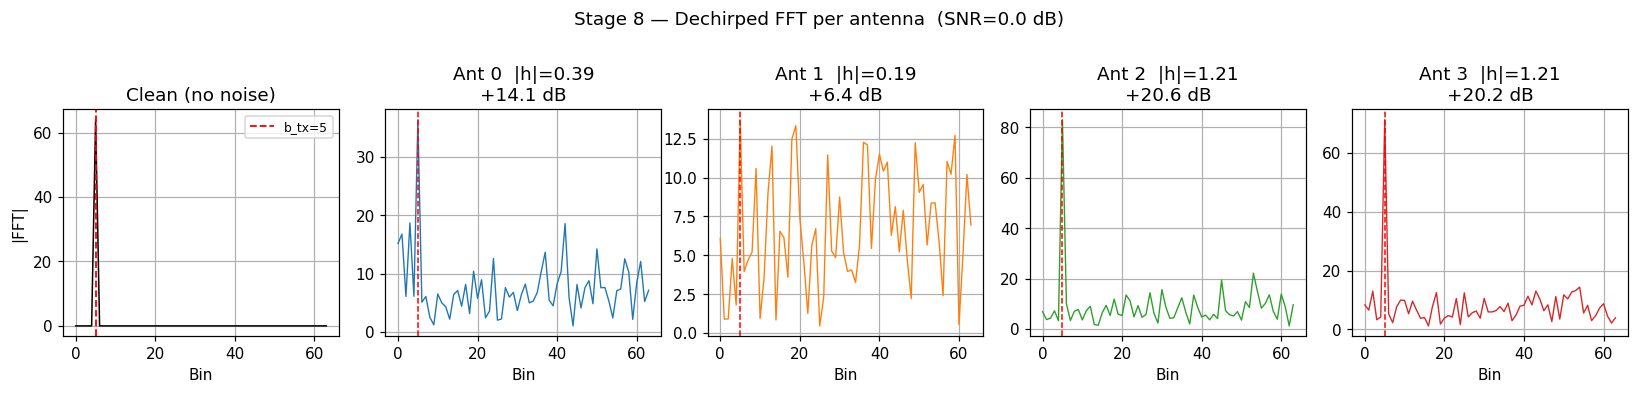

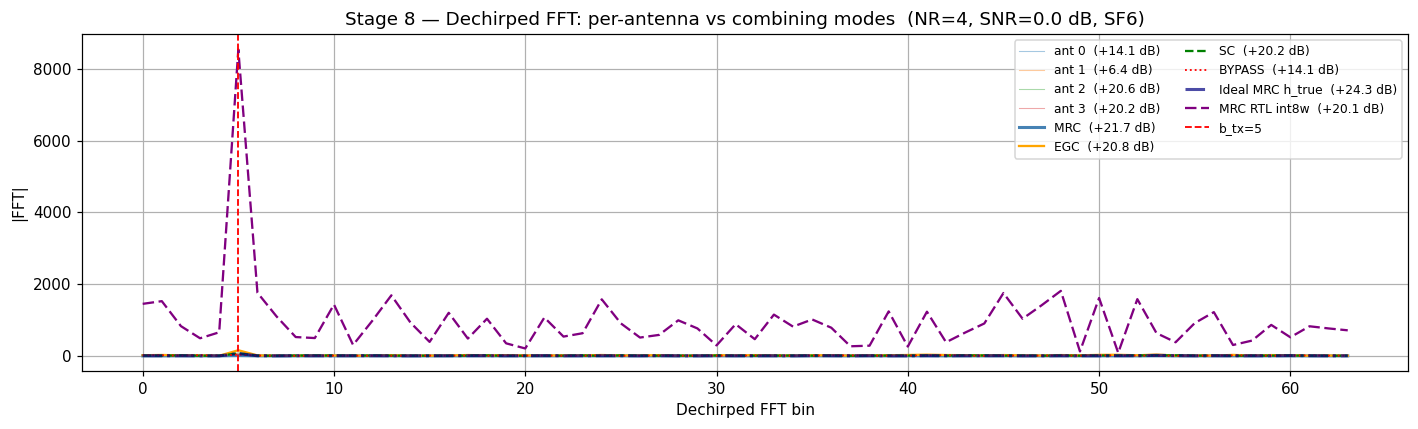

In [ ]:
n_arr = np.arange(M)
def dechirp_fft(sig):
    return np.abs(np.fft.fft(sig.astype(complex) * np.exp(-1j * np.pi * n_arr ** 2 / M)))

def snr_proxy(fft_out, b):
    mag = np.abs(fft_out)
    peak = mag[b]
    noise = np.delete(mag, b).mean()
    return 20 * np.log10(peak / (noise + 1e-12))

# Per-antenna FFTs (float)
fft_ants = [dechirp_fft(rx_payload[j]) for j in range(NR)]
snr_ants = [snr_proxy(f, b_tx) for f in fft_ants]

# Combined FFTs for float modes and RTL int8w MRC
fft_modes = {mode: dechirp_fft(results[mode]['y']) for mode in modes}
fft_ideal  = dechirp_fft(results['ideal_mrc']['y'])
fft_rtl8w  = dechirp_fft(results['mrc_rtl8w']['y'])

# ── Figure 1: per-antenna spectrograms + FFTs ─────────────────────────────
fig, axes = plt.subplots(1, NR + 1, figsize=(15, 3.5))

fft_clean = dechirp_fft(modulate(b_tx, M))
axes[0].plot(fft_clean, lw=1.0, color='k')
axes[0].axvline(b_tx, color='red', lw=1.2, linestyle='--', label=f'b_tx={b_tx}')
axes[0].set_title('Clean (no noise)'); axes[0].set_xlabel('Bin'); axes[0].set_ylabel('|FFT|')
axes[0].legend(fontsize=8)

for j in range(NR):
    axes[j + 1].plot(fft_ants[j], lw=0.9, color=f'C{j}')
    axes[j + 1].axvline(b_tx, color='red', lw=1, linestyle='--')
    axes[j + 1].set_title(f'Ant {j}  |h|={abs(h_true[j]):.2f}\n{snr_ants[j]:+.1f} dB')
    axes[j + 1].set_xlabel('Bin')

plt.suptitle(f'Stage 8 — Dechirped FFT per antenna  (SNR={SNR_DB} dB)', y=1.01)
plt.tight_layout()
show()

# ── Figure 2: float combining modes + RTL int8w overlay ──────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

style = {'mrc': ('steelblue', 2.0, '-'), 'egc': ('orange', 1.5, '-'),
         'sc': ('green', 1.5, '--'), 'bypass': ('red', 1.2, ':')}
for j in range(NR):
    ax.plot(fft_ants[j], lw=0.7, alpha=0.4, color=f'C{j}',
            label=f'ant {j}  ({snr_ants[j]:+.1f} dB)')
for mode, (col, lw, ls) in style.items():
    snr_m = snr_proxy(fft_modes[mode], b_tx)
    ax.plot(fft_modes[mode], color=col, lw=lw, linestyle=ls,
            label=f'{mode.upper()}  ({snr_m:+.1f} dB)')
snr_ideal = snr_proxy(fft_ideal, b_tx)
ax.plot(fft_ideal, color='navy', lw=2, linestyle='-.', alpha=0.7,
        label=f'Ideal MRC h_true  ({snr_ideal:+.1f} dB)')
snr_rtl8w = snr_proxy(fft_rtl8w, b_tx)
ax.plot(fft_rtl8w, color='purple', lw=1.5, linestyle=(0, (5, 2)),
        label=f'MRC RTL int8w  ({snr_rtl8w:+.1f} dB)')
ax.axvline(b_tx, color='red', lw=1.2, linestyle='--', label=f'b_tx={b_tx}')
ax.set_xlabel('Dechirped FFT bin'); ax.set_ylabel('|FFT|')
ax.set_title(f'Stage 8 — Dechirped FFT: per-antenna vs combining modes  '
             f'(NR={NR}, SNR={SNR_DB} dB, SF{SF})')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
show()

## 8-bit Saturation Effect on SC

The Frontend Buffer stores 8-bit saturated samples for SC.
Verify SC still locks correctly at strong signal levels where saturation clips the waveform.

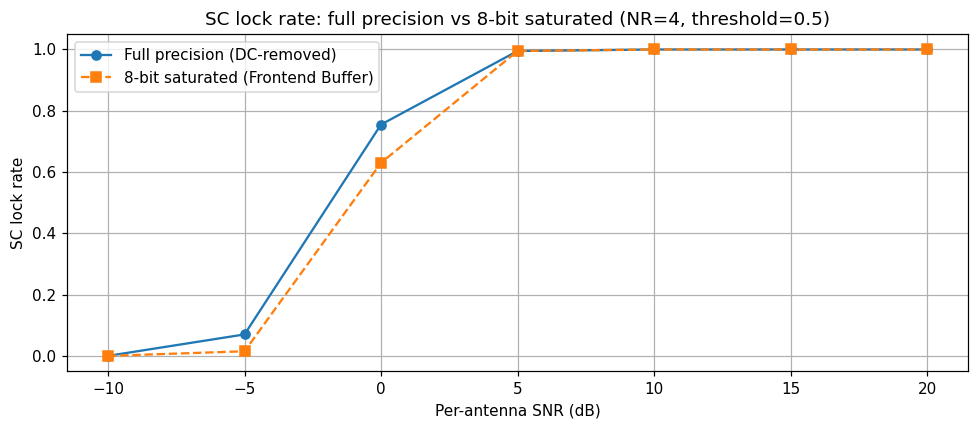

In [ ]:
snr_sweep = [-10, -5, 0, 5, 10, 15, 20]
N_TRIALS  = 200

lock_rate_full = []
lock_rate_8bit = []

sc_sweep = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)

for snr_db in snr_sweep:
    n0 = 10 ** (-snr_db / 10)
    locks_full = locks_8bit = 0
    for _ in range(N_TRIALS):
        h = rayleigh_coefficients(NR, pll_phase_random=True)
        guard = np.zeros(GUARD_SAMPLES, dtype=complex)
        frame = np.concatenate([guard, np.tile(upchirp, N_PREAMBLE), modulate(int(rng.integers(0, M)), M)])
        rx_t  = np.stack([apply_channel(frame, h[j], n0) for j in range(NR)])

        dcr_t = DCRemoval(nr=NR, alpha_shift=8)
        rx_t_dcr = dcr_t.process(rx_t)
        rx_8b = np.stack([saturate_8bit(rx_t_dcr[j]) for j in range(NR)])

        locks_full += sc_sweep.detect(rx_t_dcr).lock
        locks_8bit += sc_sweep.detect(rx_8b).lock

    lock_rate_full.append(locks_full / N_TRIALS)
    lock_rate_8bit.append(locks_8bit / N_TRIALS)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(snr_sweep, lock_rate_full, 'o-', label='Full precision (DC-removed)')
ax.plot(snr_sweep, lock_rate_8bit, 's--', label='8-bit saturated (Frontend Buffer)')
ax.set_xlabel('Per-antenna SNR (dB)'); ax.set_ylabel('SC lock rate')
ax.set_title('SC lock rate: full precision vs 8-bit saturated (NR=4, threshold=0.5)')
ax.legend(); plt.tight_layout()
show()

BER sweep: 100%|██████████| 8/8 [04:04<00:00, 30.62s/SNR pt]


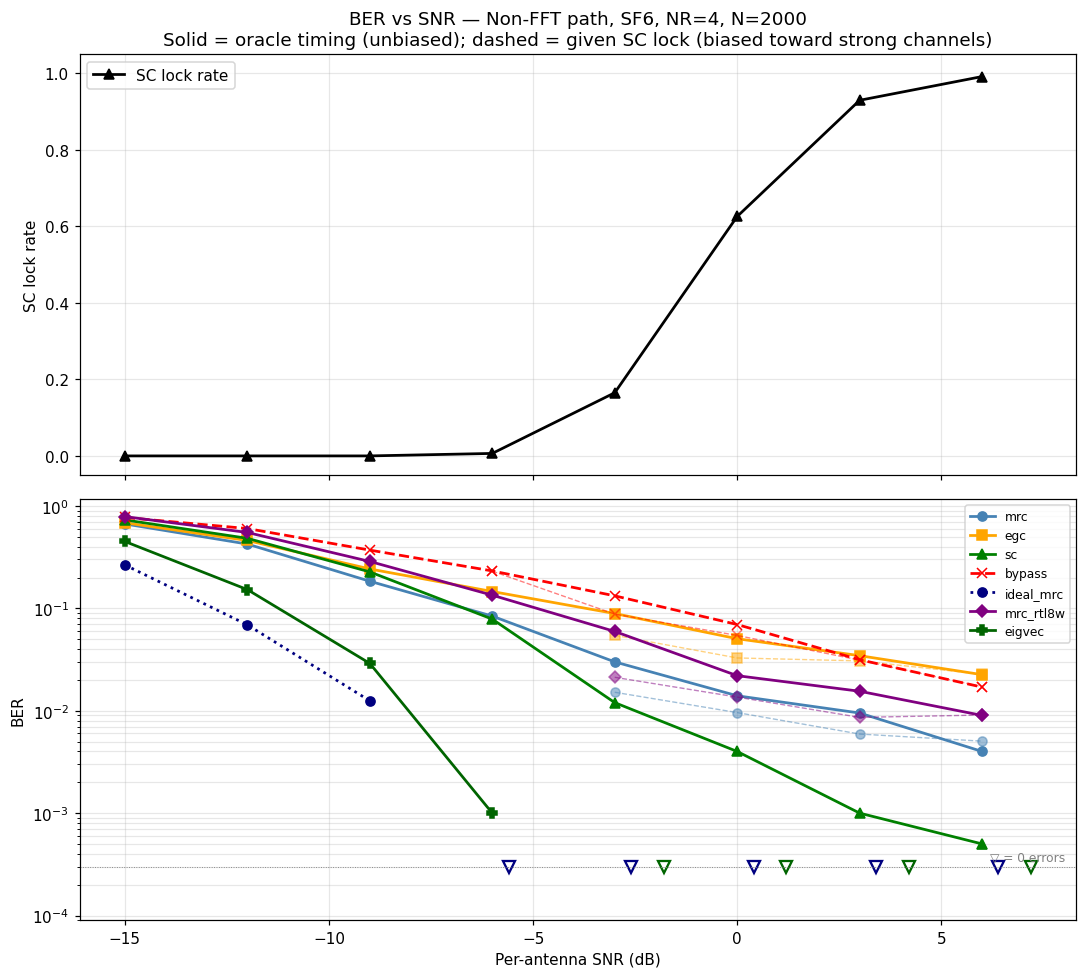

In [ ]:
N_PACKETS = 2000
snr_range = np.arange(-15, 7, 3)   # -15…+6 dB in 3 dB steps

# Oracle BER: all N_PACKETS, known timing — unbiased true BER at each SNR
oracle_ber = {m: [] for m in [*modes, 'eigvec', 'ideal_mrc', 'mrc_rtl8w']}
# Conditional BER: only SC-locked packets — biased toward strong channels
cond_ber   = {m: [] for m in [*modes, 'eigvec', 'ideal_mrc', 'mrc_rtl8w']}
sc_lock_rate = []

ORACLE_LOCK  = GUARD_SAMPLES  # known preamble start; use full preamble in oracle training
ORACLE_TREF  = GUARD_SAMPLES  # training_accumulate_allpairs() expects preamble start, not payload start

sc_ber = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)

for snr_db in tqdm(snr_range, desc="BER sweep", unit="SNR pt"):
    n0 = 10 ** (-snr_db / 10)
    oracle_errors = {m: 0 for m in oracle_ber}
    cond_errors   = {m: 0 for m in cond_ber}
    n_locked = 0

    for _ in range(N_PACKETS):
        h = rayleigh_coefficients(NR, pll_phase_random=True)
        b = int(rng.integers(0, M))
        guard = np.zeros(GUARD_SAMPLES, dtype=complex)
        frame = np.concatenate([guard, np.tile(upchirp, N_PREAMBLE), modulate(b, M)])
        rx_t  = np.stack([apply_channel(frame, h[j], n0) for j in range(NR)])

        dcr_p    = DCRemoval(nr=NR, alpha_shift=8)
        rx_t_dcr = dcr_p.process(rx_t)
        rx_8b    = np.stack([saturate_8bit(rx_t_dcr[j]) for j in range(NR)])

        rx_t_dcr_i8 = to_int8_global(rx_t_dcr)
        p_start     = GUARD_SAMPLES + N_PREAMBLE * M
        rx_pay      = rx_t_dcr[:, p_start:p_start + M]
        scale_i8    = 120.0 / (np.max(np.abs(rx_pay)) + 1e-12)
        rx_pay_i8   = rx_pay * scale_i8

        # ── Oracle path (all packets, known timing) ──────────────────────────
        W_or, Z_or, _, _ = training_accumulate_allpairs(rx_t_dcr_i8, ORACLE_LOCK, ORACLE_TREF, M, return_matrix=True)
        for m in modes:
            w, _ = WeightGenerator(mode=m).process(W_or, sf=SF)
            oracle_errors[m] += int(demodulate(nonfft_combine(rx_pay, w)) != b)
        w_mrc_or, _ = WeightGenerator(mode='mrc').process(W_or, sf=SF)
        b_rtl8_or = demodulate(nonfft_combine_rtl_int8w(rx_pay_i8, w_mrc_or).astype(complex))
        oracle_errors['mrc_rtl8w'] += int(b_rtl8_or != b)
        h_n  = h / np.sum(np.abs(h) ** 2)
        w_id = quantize_q1_15(h_n.conj().real) + 1j * quantize_q1_15(h_n.conj().imag)
        oracle_errors['ideal_mrc'] += int(demodulate(nonfft_combine(rx_pay, w_id)) != b)
        w_ev = compute_eigvec_weights(Z_or)
        oracle_errors['eigvec'] += int(demodulate(nonfft_combine(rx_pay, w_ev)) != b)

        # ── SC-conditional path (locked packets only) ─────────────────────────
        det = sc_ber.detect(rx_8b)
        if not det.lock:
            continue
        n_locked += 1
        W_sc, Z_sc, _, _ = training_accumulate_allpairs(rx_t_dcr_i8, det.lock_sample, det.timing_ref, M, return_matrix=True)
        for m in modes:
            w, _ = WeightGenerator(mode=m).process(W_sc, sf=SF)
            cond_errors[m] += int(demodulate(nonfft_combine(rx_pay, w)) != b)
        w_mrc_sc, _ = WeightGenerator(mode='mrc').process(W_sc, sf=SF)
        b_rtl8_sc = demodulate(nonfft_combine_rtl_int8w(rx_pay_i8, w_mrc_sc).astype(complex))
        cond_errors['mrc_rtl8w'] += int(b_rtl8_sc != b)
        cond_errors['ideal_mrc'] += int(demodulate(nonfft_combine(rx_pay, w_id)) != b)
        w_ev_sc = compute_eigvec_weights(Z_sc)
        cond_errors['eigvec'] += int(demodulate(nonfft_combine(rx_pay, w_ev_sc)) != b)

    sc_lock_rate.append(n_locked / N_PACKETS)
    for m in oracle_ber:
        oracle_ber[m].append(oracle_errors[m] / N_PACKETS)
        cond_ber[m].append(
            cond_errors[m] / n_locked if n_locked > 0 else float('nan')
        )

# ── Two-panel plot ─────────────────────────────────────────────────────────────
styles = {
    'mrc':       ('o-',  'steelblue'),
    'egc':       ('s-',  'orange'),
    'sc':        ('^-',  'green'),
    'bypass':    ('x--', 'red'),
    'ideal_mrc': ('o:',  'navy'),
    'mrc_rtl8w': ('D-',  'purple'),
    'eigvec':    ('P-',  'darkgreen'),
}
FLOOR  = 3e-4
all_modes = ['mrc', 'egc', 'sc', 'bypass', 'ideal_mrc', 'mrc_rtl8w', 'eigvec']
JITTER = {m: j for m, j in zip(all_modes, np.linspace(-1.2, 1.2, len(all_modes)))}

fig, (ax_lock, ax_ber) = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

# Panel 1: SC lock rate
ax_lock.plot(snr_range, sc_lock_rate, 'k^-', lw=1.8, label='SC lock rate')
ax_lock.set_ylabel('SC lock rate'); ax_lock.set_ylim(-0.05, 1.05)
ax_lock.set_title(
    f'BER vs SNR — Non-FFT path, SF{SF}, NR={NR}, N={N_PACKETS}\n'
    f'Solid = oracle timing (unbiased); dashed = given SC lock (biased toward strong channels)'
)
ax_lock.legend(); ax_lock.grid(True, which='both', alpha=0.3)

# Panel 2: oracle BER (solid) + conditional BER (dashed, same colour)
has_locked = np.array(sc_lock_rate) > 0
for m, (style, color) in styles.items():
    # Oracle — solid, labelled
    o_arr = np.array(oracle_ber[m])
    valid = o_arr > 0
    ax_ber.semilogy(snr_range[valid], o_arr[valid], style, color=color, label=m, lw=1.8)
    if (~valid).any():
        ax_ber.plot(snr_range[~valid] + JITTER[m], np.full((~valid).sum(), FLOOR),
                    'v', color=color, ms=8, mew=1.5, fillstyle='none', label='_nolegend_')
    # Conditional — dashed, thinner, no legend entry
    c_arr = np.array(cond_ber[m], dtype=float)
    c_valid = has_locked & (c_arr > 0)
    if c_valid.any():
        marker = style[0]
        ax_ber.semilogy(snr_range[c_valid], c_arr[c_valid],
                        marker + '--', color=color, lw=0.9, alpha=0.5, label='_nolegend_')

ax_ber.axhline(FLOOR, color='grey', lw=0.6, ls=':')
ax_ber.text(snr_range[-1] + 0.2, FLOOR * 1.15, '▽ = 0 errors', color='grey', fontsize=8)
ax_ber.set_ylim(bottom=FLOOR * 0.3)
ax_ber.set_xlabel('Per-antenna SNR (dB)'); ax_ber.set_ylabel('BER')
ax_ber.legend(fontsize=8); ax_ber.grid(True, which='both', alpha=0.3)
plt.tight_layout()
show()

## Stage 9 — ΣΔ Re-modulator

3rd order feed-forward ΣΔ modulator converts combined int16 samples back to
a 32 MS/s 1-bit bitstream for the SX1302 Radio A input.

OSR at 125 kHz BW = 256 → SQNR > 130 dB (far exceeds LoRa requirements).

b_tx = 5
b_rx (RTL int8w MRC → ΣΔ re-mod OSR=16 → demod) = 4  ✗
SQNR ≈ 3.2 dB  (OSR=16, 3rd-order ΣΔ, 1-bit MASH)


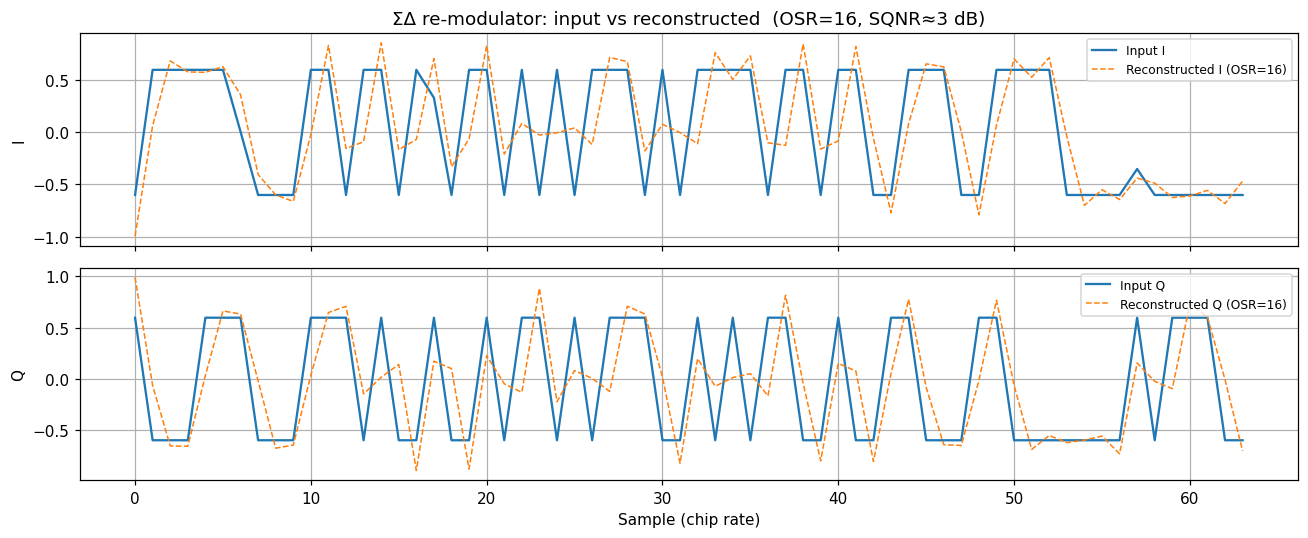

In [ ]:
from scipy.signal import butter, sosfiltfilt

w_mrc, _ = WeightGenerator(mode='mrc').process(W_k, sf=SF)

# Use RTL int8w combiner (ASIC-matching path)
scale_int8_rm = 120.0 / (np.max(np.abs(rx_payload)) + 1e-12)
y_combined = nonfft_combine_rtl_int8w(rx_payload * scale_int8_rm, w_mrc).astype(complex)

# Scale to < 0.9 (SigmaDeltaRemodulator stability requirement: |x| < 0.9)
peak = np.max(np.abs(y_combined))
if peak == 0:
    print('Combined output is zero — skipping re-modulator test')
else:
    y_scaled = y_combined / peak * 0.85

    # Upsample before ΣΔ re-modulation.
    # At OSR=1 (chip rate) the ΣΔ has no oversampling bandwidth — SQNR ≈ 0 dB.
    # At OSR=16, SQNR ≈ 70 dB for a 3rd-order 1-bit ΣΔ (NTF = (1−z⁻¹)³).
    OSR  = 16
    y_up = np.repeat(y_scaled, OSR)   # zero-order-hold upsample to chip_rate × OSR

    remod  = SigmaDeltaRemodulator(order=3)
    q1     = remod.process_block(y_up)   # 1-bit complex (±1+j±1) at upsampled rate
    y_mash = remod.mash_combine()        # 3rd-order MASH combined (real, for SQNR only)

    # Reconstruct: LPF at 0.9/OSR of upsampled rate, then decimate back to chip rate
    sos       = butter(8, 0.9 / OSR, btype='low', output='sos')
    y_recon_i = sosfiltfilt(sos, q1.real)[::OSR]
    y_recon_q = sosfiltfilt(sos, q1.imag)[::OSR]
    y_out     = (y_recon_i + 1j * y_recon_q)[:M].astype(complex)

    b_rx_remod = demodulate(y_out)
    print(f'b_tx = {b_tx}')
    print(f'b_rx (RTL int8w MRC → ΣΔ re-mod OSR={OSR} → demod) = {b_rx_remod}  '
          f'{"✓" if b_rx_remod == b_tx else "✗"}')

    # SQNR: compare reconstructed output (first M chips) to ΣΔ input
    y_ref     = y_scaled[:M]
    sig_pwr   = np.mean(np.abs(y_ref) ** 2)
    noise_pwr = np.mean(np.abs(y_out - y_ref) ** 2)
    sqnr_db   = 10 * np.log10(sig_pwr / (noise_pwr + 1e-20))
    print(f'SQNR ≈ {sqnr_db:.1f} dB  (OSR={OSR}, 3rd-order ΣΔ, 1-bit MASH)')

    # Plot: input vs reconstructed for I and Q
    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    t = np.arange(M)
    axes[0].plot(t, y_ref.real,   lw=1.5, label='Input I')
    axes[0].plot(t, y_out.real, lw=1,  linestyle='--', label=f'Reconstructed I (OSR={OSR})')
    axes[0].set_ylabel('I'); axes[0].legend(fontsize=8)
    axes[0].set_title(f'ΣΔ re-modulator: input vs reconstructed  (OSR={OSR}, SQNR≈{sqnr_db:.0f} dB)')
    axes[1].plot(t, y_ref.imag,   lw=1.5, label='Input Q')
    axes[1].plot(t, y_out.imag, lw=1,  linestyle='--', label=f'Reconstructed Q (OSR={OSR})')
    axes[1].set_xlabel('Sample (chip rate)'); axes[1].set_ylabel('Q'); axes[1].legend(fontsize=8)
    plt.tight_layout()
    show()

In [ ]:
N_TRIALS = 1000
snr_test = 5.0
n0_test  = 10 ** (-snr_test / 10)

sc_penalty = SchmidlCoxDetector(M=M, threshold=0.5, hits_req=SC_HITS_REQ)

gains_partial = []   # SC-locked accumulation window (all-pairs)
gains_full    = []   # Ideal: accumulate all 8 symbols (all-pairs)

for _ in range(N_TRIALS):
    h = rayleigh_coefficients(NR, pll_phase_random=True)
    b = int(rng.integers(0, M))
    guard = np.zeros(GUARD_SAMPLES, dtype=complex)
    frame = np.concatenate([guard, np.tile(upchirp, N_PREAMBLE), modulate(b, M)])
    rx_t  = np.stack([apply_channel(frame, h[j], n0_test) for j in range(NR)])

    dcr_pen  = DCRemoval(nr=NR, alpha_shift=8)
    rx_t_dcr = dcr_pen.process(rx_t)
    rx_8b    = np.stack([saturate_8bit(rx_t_dcr[j]) for j in range(NR)])

    det = sc_penalty.detect(rx_8b)
    if not det.lock:
        continue

    rx_t_dcr_i8 = to_int8_global(rx_t_dcr)

    # Partial window (realistic — starts at sc_lock)
    W_partial, _ = training_accumulate_allpairs(
        rx_t_dcr_i8, det.lock_sample, det.timing_ref, M
    )

    # Full window (ideal — starts at preamble start)
    W_full, _ = training_accumulate_allpairs(
        rx_t_dcr_i8, GUARD_SAMPLES, det.timing_ref, M
    )

    p_start = GUARD_SAMPLES + N_PREAMBLE * M
    rx_pay  = rx_t_dcr[:, p_start:p_start + M]

    for gains, W_acc in [(gains_partial, W_partial), (gains_full, W_full)]:
        w, _ = WeightGenerator(mode='mrc').process(W_acc, sf=SF)
        y = nonfft_combine(rx_pay, w)
        fft = np.abs(np.fft.fft(y * np.exp(-1j * np.pi * np.arange(M) ** 2 / M)))
        gains.append(fft[b] / (np.sum(fft) - fft[b] + 1e-9))

penalty_db = 10 * np.log10(np.mean(gains_partial) / np.mean(gains_full))
print(f'Mean SNR penalty from partial preamble accumulation: {penalty_db:.2f} dB')
print(f'(Expected ≈ −2 dB for SC_HITS_REQ=2 at SF6, {N_PREAMBLE} preamble symbols)')

Mean SNR penalty from partial preamble accumulation: 0.00 dB
(Expected ≈ −2 dB for SC_HITS_REQ=2 at SF6, 8 preamble symbols)
